In [40]:
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Add project root to python path

sys.path.append("../")

from src.config import RAW_DATA
from src.data_loader import DataLoader
from src.schema_validator import SchemaValidator
from src.preprocessing import Preprocessor
from src.visualization import Visualizer
from src.enrichment import *
from src.utils import *

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [41]:
loader = DataLoader(RAW_DATA)


In [42]:
data = loader.load_excel(
    "ethiopia_fi_unified_data.xlsx",
    sheet_name="ethiopia_fi_unified_data"
)

impact = loader.load_excel(
    "ethiopia_fi_unified_data.xlsx",
    sheet_name="Impact_sheet"
)

reference = loader.load_excel(
    "reference_codes.xlsx"
)

print(data.shape)

print(impact.shape)

print(reference.shape)

2026-07-16 15:52:53,590 - INFO - ethiopia_fi_unified_data.xlsx loaded successfully
2026-07-16 15:52:53,607 - INFO - ethiopia_fi_unified_data.xlsx loaded successfully
2026-07-16 15:52:53,617 - INFO - reference_codes.xlsx loaded successfully


(43, 34)
(14, 35)
(71, 4)


In [43]:
data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [44]:
impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [46]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     str           
 1   record_type          43 non-null     str           
 2   category             10 non-null     str           
 3   pillar               33 non-null     str           
 4   indicator            43 non-null     str           
 5   indicator_code       43 non-null     str           
 6   indicator_direction  33 non-null     str           
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     str           
 9   value_type           43 non-null     str           
 10  unit                 33 non-null     str           
 11  observation_date     43 non-null     datetime64[us]
 12  period_start         10 non-null     datetime64[us]
 13  period_end           10 non-null     datetime64[

In [47]:
impact.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            14 non-null     str           
 1   parent_id            14 non-null     str           
 2   record_type          14 non-null     str           
 3   category             0 non-null      float64       
 4   pillar               14 non-null     str           
 5   indicator            14 non-null     str           
 6   indicator_code       0 non-null      float64       
 7   indicator_direction  0 non-null      float64       
 8   value_numeric        12 non-null     float64       
 9   value_text           0 non-null      float64       
 10  value_type           14 non-null     str           
 11  unit                 14 non-null     str           
 12  observation_date     14 non-null     datetime64[us]
 13  period_start         0 non-null      float64    

In [48]:
reference.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   field        71 non-null     str  
 1   code         71 non-null     str  
 2   description  71 non-null     str  
 3   applies_to   71 non-null     str  
dtypes: str(4)
memory usage: 2.3 KB


In [49]:
print(data.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


In [50]:
validator = SchemaValidator(impact)

validator.run_all()

2026-07-16 15:52:53,727 - INFO - Required columns exist.
2026-07-16 15:52:53,728 - INFO - Duplicate Record IDs : 0
2026-07-16 15:52:53,730 - INFO - Schema validation complete.


In [51]:
missing_summary(data)

,Missing,Percent
lag_months,43,100.000000
region,43,100.000000
impact_estimate,43,100.000000
relationship_type,43,100.000000
evidence_basis,43,100.000000
notes,43,100.000000
related_indicator,43,100.000000
impact_magnitude,43,100.000000
impact_direction,43,100.000000
category,33,76.744186


In [52]:
validator.duplicate_records()

2026-07-16 15:52:53,746 - INFO - Duplicate Record IDs : 0


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


In [53]:
record_counts = (

    data["record_type"]

    .value_counts()

    .reset_index()

)

record_counts.columns=[

    "Record Type",

    "Count"

]

record_counts

,Record Type,Count
0,observation,30
1,event,10
2,target,3


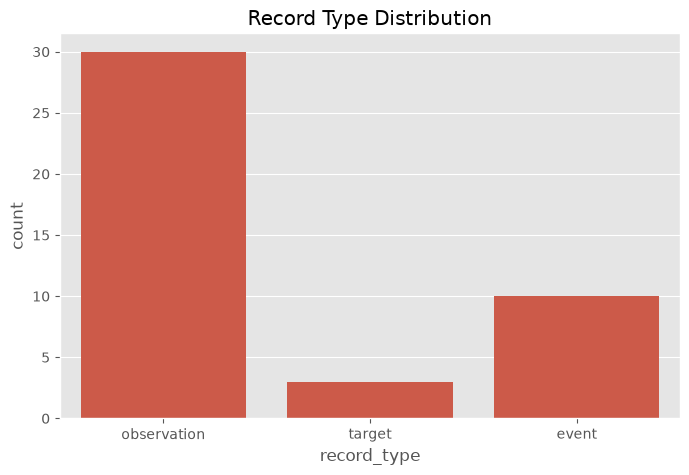

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=data,

    x="record_type"

)

plt.title("Record Type Distribution")

plt.show()

In [55]:
pillar_counts = (

    data["pillar"]

    .value_counts()

)

pillar_counts

pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

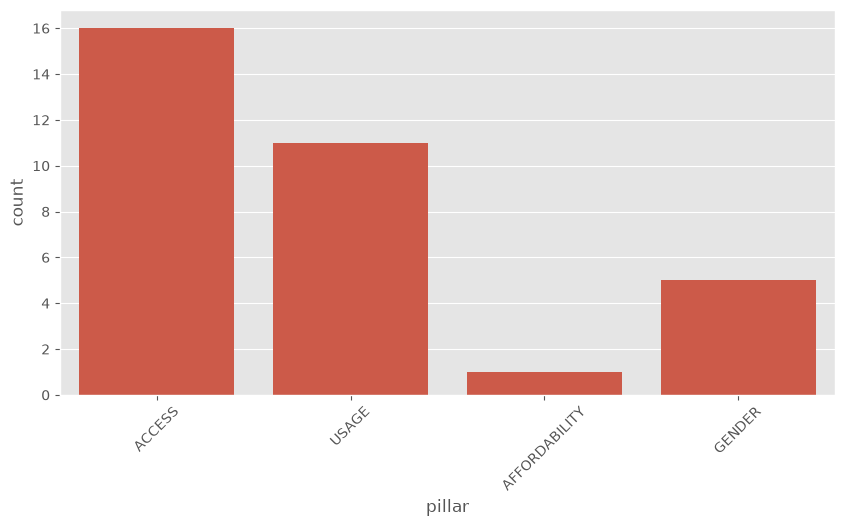

In [56]:
plt.figure(figsize=(10,5))

sns.countplot(

    data=data,

    x="pillar"

)

plt.xticks(rotation=45)

plt.show()

In [57]:
source_counts = (

    data["source_type"]

    .value_counts()

)

source_counts

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

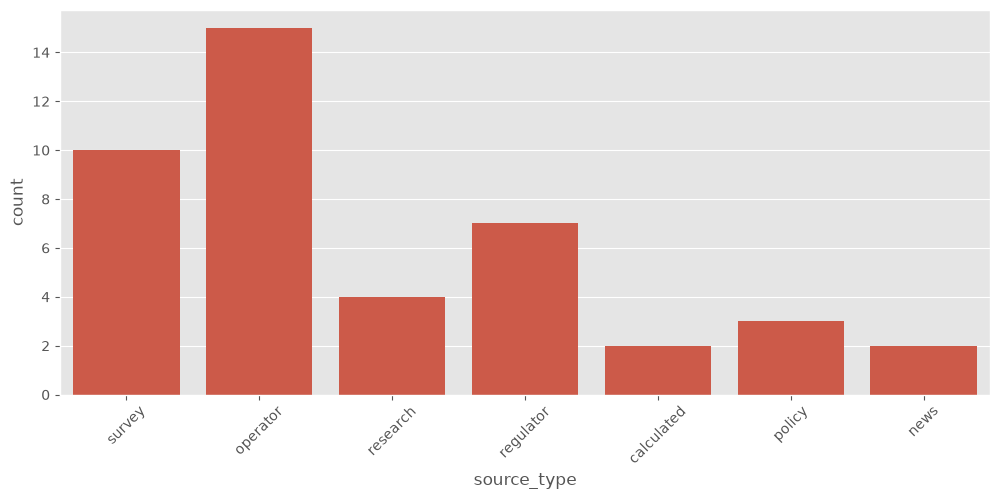

In [58]:
plt.figure(figsize=(12,5))

sns.countplot(

    data=data,

    x="source_type"

)

plt.xticks(rotation=45)

plt.show()

In [59]:
obs = data[

    data.record_type=="observation"

]

obs.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [60]:
events = data[

    data.record_type=="event"

]

events.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaT,NaT,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaT,NaT,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaT,NaT,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaT,NaT,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaT,NaT,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN


In [61]:
targets = data[

    data.record_type=="target"

]

targets.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
30,REC_0031,target,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,70.0,NaN,percentage,%,2025-12-31,NaT,NaT,2025,all,national,NaN,NFIS-II Strategy,policy,https://nbe.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NFIS-II target,NaN
31,REC_0032,target,NaN,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,90000000.0,NaN,count,people,2028-12-31,NaT,NaT,2028,all,national,NaN,Fayda/NIDP,policy,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,90M by 2028 target,NaN
32,REC_0033,target,NaN,GENDER,Female Mobile Money Account Share,GEN_MM_SHARE,higher_better,50.0,NaN,percentage,%,2030-12-31,NaT,NaT,2030,female,national,NaN,NBE,policy,NaN,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Parity target,NaN


In [62]:
impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [63]:
obs["observation_date"] = pd.to_datetime(

    obs["observation_date"]

)

In [64]:
print(

    obs["observation_date"].min()

)

print(

    obs["observation_date"].max()

)

2014-12-31 00:00:00
2025-12-31 00:00:00


In [65]:
timeline = (

    obs

    .groupby(

        obs["observation_date"].dt.year

    )

    .size()

)

timeline

observation_date
2014     1
2017     1
2021     5
2023     1
2024    11
2025    11
dtype: int64

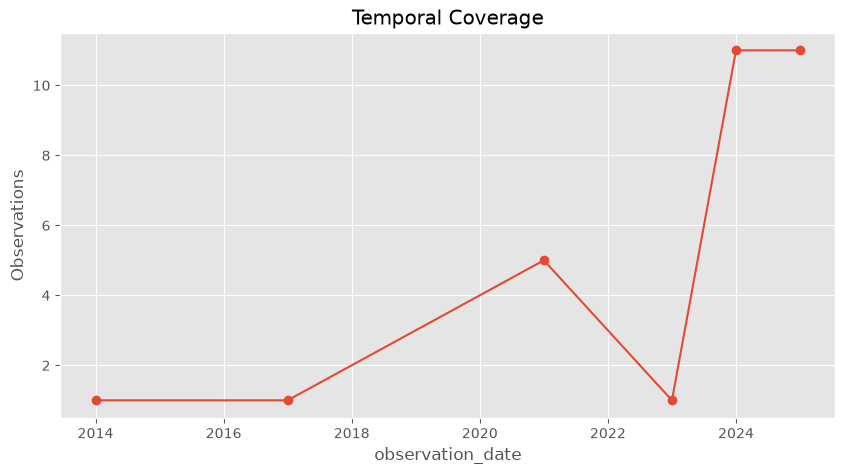

In [66]:
timeline.plot(

    marker="o",

    figsize=(10,5)

)

plt.ylabel("Observations")

plt.title("Temporal Coverage")

plt.grid(True)

plt.show()

In [67]:
indicator_counts=(

    obs["indicator_code"]

    .value_counts()

)

indicator_counts

indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
Name: count, dtype: int64

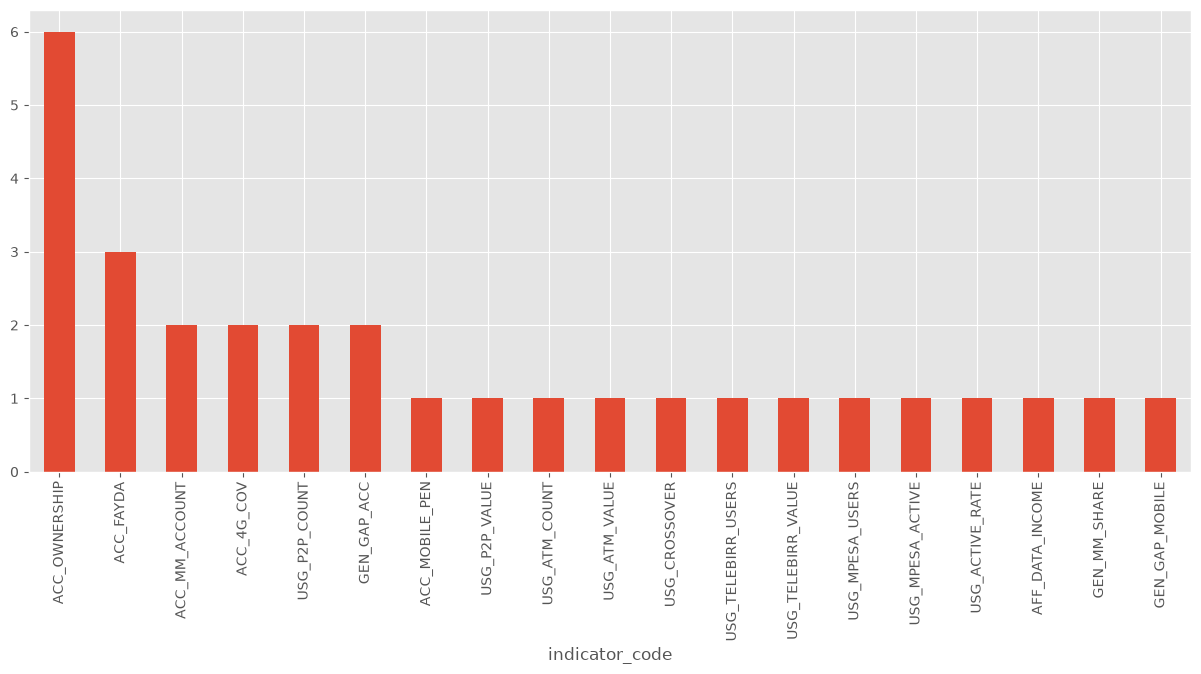

In [68]:
plt.figure(figsize=(15,6))

indicator_counts.plot.bar()

plt.xticks(rotation=90)

plt.show()

Confidence Counts:
confidence
high      40
medium     3
Name: count, dtype: int64


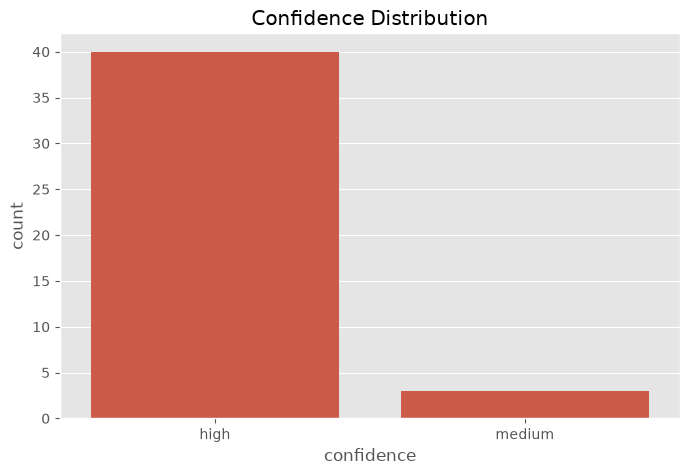

In [69]:
confidence_counts = (
    data["confidence"]
    .value_counts()
)

print("Confidence Counts:")
print(confidence_counts)

plt.figure(figsize=(8,5))
sns.countplot(
    data=data,
    x="confidence"
)
plt.title("Confidence Distribution")
plt.show()

In [70]:
sorted(

    obs["indicator_code"]

    .unique()

)

['ACC_4G_COV',
 'ACC_FAYDA',
 'ACC_MM_ACCOUNT',
 'ACC_MOBILE_PEN',
 'ACC_OWNERSHIP',
 'AFF_DATA_INCOME',
 'GEN_GAP_ACC',
 'GEN_GAP_MOBILE',
 'GEN_MM_SHARE',
 'USG_ACTIVE_RATE',
 'USG_ATM_COUNT',
 'USG_ATM_VALUE',
 'USG_CROSSOVER',
 'USG_MPESA_ACTIVE',
 'USG_MPESA_USERS',
 'USG_P2P_COUNT',
 'USG_P2P_VALUE',
 'USG_TELEBIRR_USERS',
 'USG_TELEBIRR_VALUE']

In [71]:
events[[

    "indicator",

    "category",

    "observation_date"

]]

,indicator,category,observation_date
33,Telebirr Launch,product_launch,2021-05-17
34,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,Foreign Exchange Liberalization,policy,2024-07-29
38,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,M-Pesa EthSwitch Integration,partnership,2025-10-27
40,EthioPay Instant Payment System Launch,infrastructure,2025-12-18
41,NFIS-II Strategy Launch,policy,2021-09-01
42,Safaricom Ethiopia Price Increase,pricing,2025-12-15


In [72]:
events = events.sort_values(

    "observation_date"

)

events

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaT,NaT,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
41,EVT_0009,event,policy,NaN,NFIS-II Strategy Launch,EVT_NFIS2,NaN,NaN,Launched,categorical,NaN,2021-09-01,2021-09-01,2025-06-30,2021,all,national,NaN,NBE,regulator,https://nbe.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,5-year national financial inclusion strategy,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaT,NaT,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaT,NaT,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaT,NaT,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaT,NaT,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN
38,EVT_0006,event,milestone,NaN,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,NaN,NaN,Achieved,categorical,NaN,2024-10-01,NaT,NaT,FY2024/25,all,national,NaN,EthSwitch,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Historic: digital > cash for first time,NaN
39,EVT_0007,event,partnership,NaN,M-Pesa EthSwitch Integration,EVT_MPESA_INTEROP,NaN,NaN,Launched,categorical,NaN,2025-10-27,NaT,NaT,FY2025/26,all,national,NaN,EthSwitch,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Full interoperability for M-Pesa,NaN
42,EVT_0010,event,pricing,NaN,Safaricom Ethiopia Price Increase,EVT_SAFCOM_PRICE,NaN,NaN,Implemented,categorical,NaN,2025-12-15,NaT,NaT,2025,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Data and voice prices increased 20-82%,NaN
40,EVT_0008,event,infrastructure,NaN,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,NaN,NaN,Launched,categorical,NaN,2025-12-18,NaT,NaT,FY2025/26,all,national,NaN,NBE/EthSwitch,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National real-time payment system,NaN


In [73]:
impact[[

    "parent_id",

    "pillar",

    "related_indicator",

    "impact_direction",

    "impact_magnitude",

    "lag_months"

]]

,parent_id,pillar,related_indicator,impact_direction,impact_magnitude,lag_months
0,EVT_0001,ACCESS,ACC_OWNERSHIP,increase,high,12
1,EVT_0001,USAGE,USG_TELEBIRR_USERS,increase,high,3
2,EVT_0001,USAGE,USG_P2P_COUNT,increase,high,6
3,EVT_0002,ACCESS,ACC_4G_COV,increase,medium,12
4,EVT_0002,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12
5,EVT_0003,USAGE,USG_MPESA_USERS,increase,high,3
6,EVT_0003,ACCESS,ACC_MM_ACCOUNT,increase,medium,6
7,EVT_0004,ACCESS,ACC_OWNERSHIP,increase,medium,24
8,EVT_0004,GENDER,GEN_GAP_ACC,decrease,medium,24
9,EVT_0005,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3


In [74]:
merged = impact.merge(

    events,

    left_on="parent_id",

    right_on="record_id",

    suffixes=(

        "_impact",

        "_event"

    )

)

merged.head()

,record_id_impact,parent_id,record_type_impact,category_impact,pillar_impact,indicator_impact,indicator_code_impact,indicator_direction_impact,value_numeric_impact,value_text_impact,value_type_impact,unit_impact,observation_date_impact,period_start_impact,period_end_impact,fiscal_year_impact,gender_impact,location_impact,region_impact,source_name_impact,source_type_impact,source_url_impact,confidence_impact,related_indicator_impact,relationship_type_impact,impact_direction_impact,impact_magnitude_impact,impact_estimate_impact,lag_months_impact,evidence_basis_impact,comparable_country_impact,collected_by_impact,collection_date_impact,original_text_impact,notes_impact,record_id_event,record_type_event,category_event,pillar_event,indicator_event,indicator_code_event,indicator_direction_event,value_numeric_event,value_text_event,value_type_event,unit_event,observation_date_event,period_start_event,period_end_event,fiscal_year_event,gender_event,location_event,region_event,source_name_event,source_type_event,source_url_event,confidence_event,related_indicator_event,relationship_type_event,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaT,NaT,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaT,NaT,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaT,NaT,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaT,NaT,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Comm

In [75]:
pd.crosstab(

    merged["indicator_impact"],

    merged["pillar_impact"]

)

pillar_impact,ACCESS,AFFORDABILITY,GENDER,USAGE
indicator_impact,,,,
EthioPay effect on P2P Count,0,0,0,1
FX Reform effect on Data Affordability,0,1,0,0
Fayda effect on Account Ownership,1,0,0,0
Fayda effect on Gender Gap,0,0,1,0
M-Pesa Interop effect on M-Pesa Active Users,0,0,0,1
M-Pesa Interop effect on P2P Count,0,0,0,1
M-Pesa effect on M-Pesa Users,0,0,0,1
M-Pesa effect on Mobile Money Account Rate,1,0,0,0
Safaricom Price Hike effect on Data Affordability,0,1,0,0


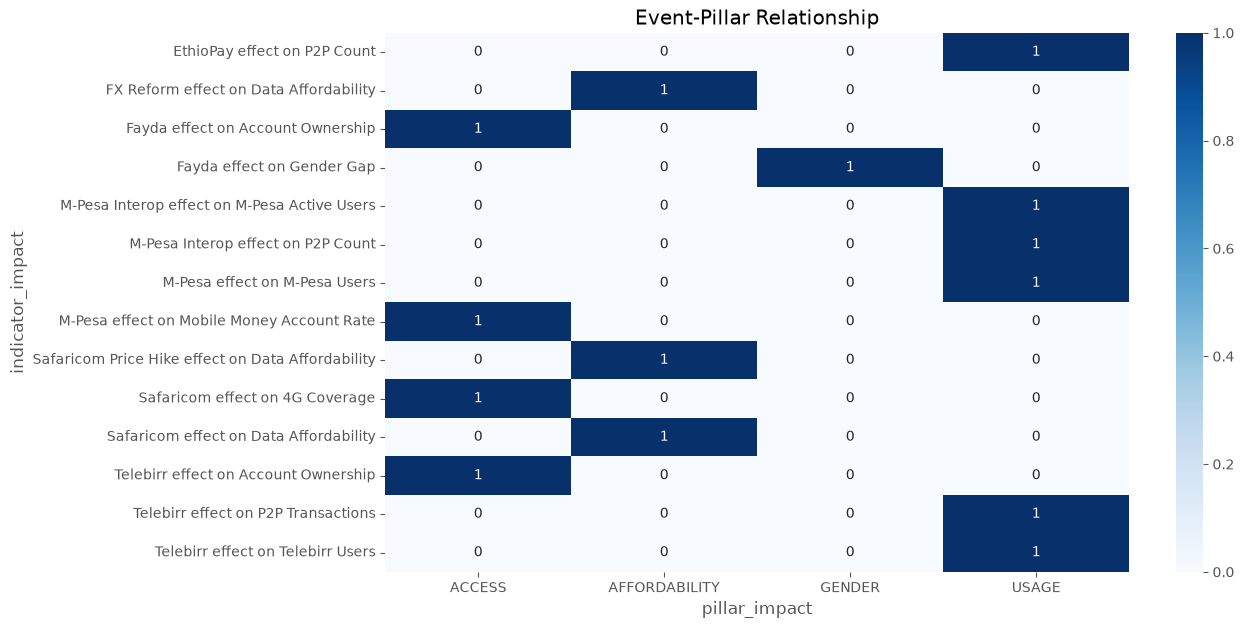

In [76]:
matrix = pd.crosstab(

    merged["indicator_impact"],

    merged["pillar_impact"]

)

plt.figure(figsize=(12,7))

sns.heatmap(

    matrix,

    annot=True,

    cmap="Blues"

)

plt.title(

    "Event-Pillar Relationship"

)

plt.show()

In [77]:
obs_new = create_observations()

events_new = create_events()

impact_new = create_impact_links()

updated_data = pd.concat(

    [

        data,

        obs_new,

        events_new

    ],

    ignore_index=True

)

updated_impact = pd.concat(

    [

        impact,

        impact_new

    ],

    ignore_index=True

)

In [78]:
updated_data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [79]:
updated_impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [80]:
updated_data.to_excel(

    "../data/processed/ethiopia_fi_unified_data_updated.xlsx",

    index=False

)

updated_impact.to_excel(

    "../data/processed/impact_links_updated.xlsx",

    index=False

)

In [81]:
print(updated_data.shape)
print(updated_data.columns.tolist())
display(updated_data.head())

(46, 34)
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [82]:
print(updated_impact.shape)
print(updated_impact.columns.tolist())
display(updated_impact.head())

(15, 35)
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices
